## Ejercicio hiperparametrización breast cancer de sklearn

1. Carga el dataset [breast_cancer de `sklearn`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)
2. Prueba al menos 5 modelos diferentes de clasificación y aplica un GridSearchCV mediante Pipelines. Aplica también un RandomizedSearchCV.
3. Conclusiones. Guarda el modelo final en un archivo con pickle.

In [19]:
# librerías de python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import load_breast_cancer

In [20]:
# datos del dataset de cáncer
ds_cancer = load_breast_cancer()
ds_cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [21]:
# descripción del dataset
print(ds_cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [22]:
# el df con su X, y
X = pd.DataFrame(ds_cancer.data, columns= ds_cancer.feature_names)
y = pd.Series(ds_cancer.target, name= "target")

df = pd.concat([X, y], axis=1)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [23]:
# info del df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [24]:
# describe del df
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [25]:
# value counts normalizado del target, ¿está balanceado?
df["target"].value_counts(normalize=True)

target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

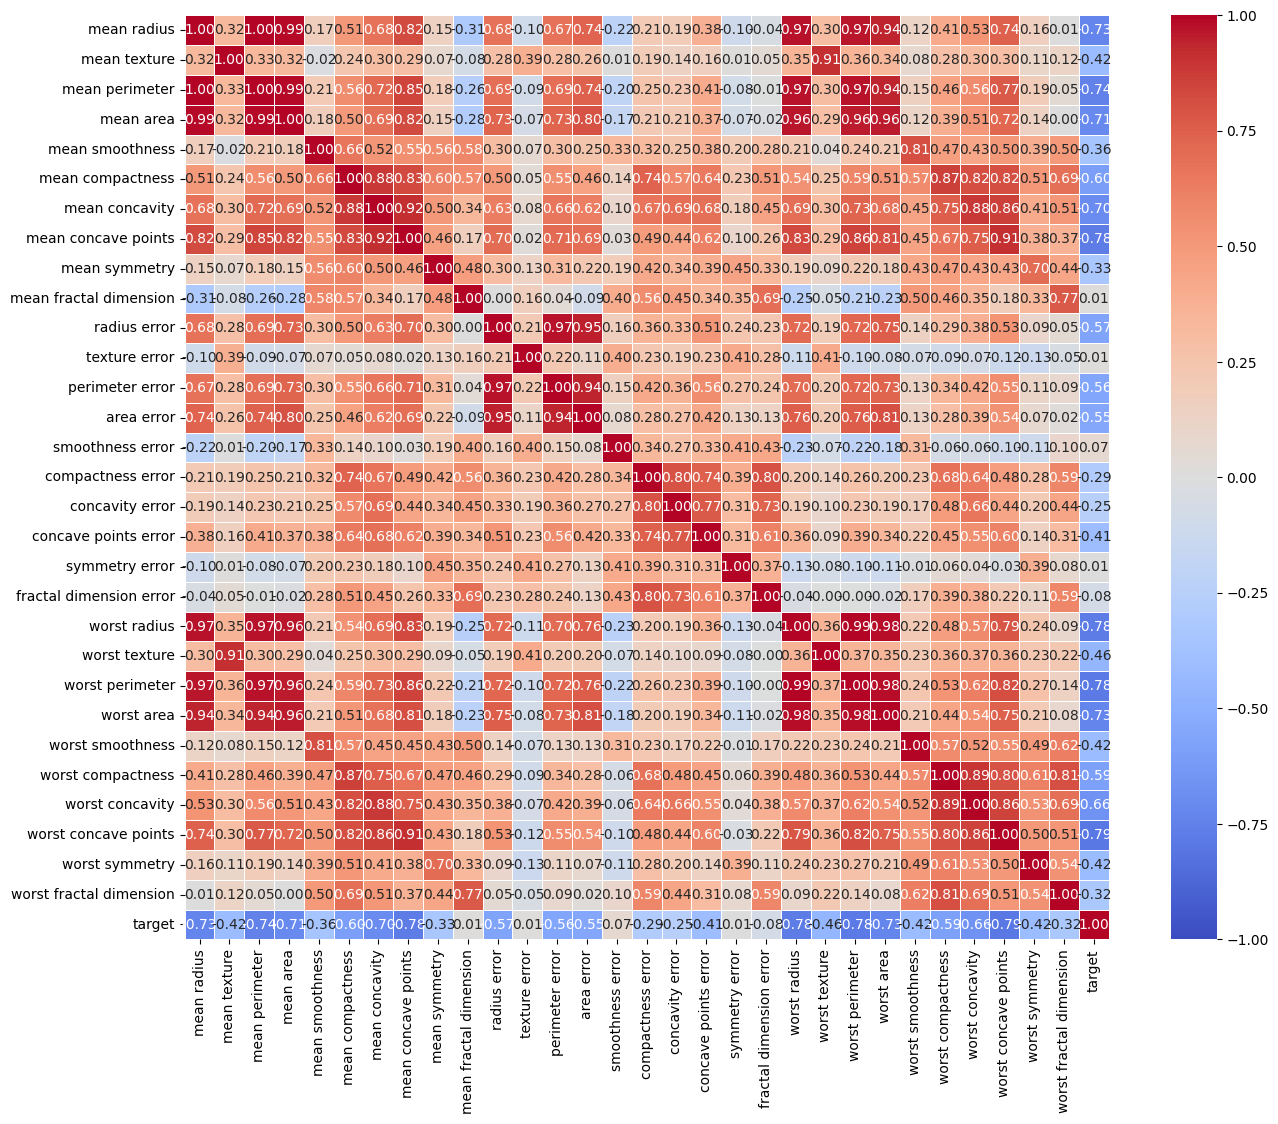

In [26]:
corr = df.select_dtypes('number').corr()
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f',
 cmap='coolwarm', center=0, vmin=-1, vmax=1,
 square=True, linewidths=0.5, ax=ax)
plt.show()
# heatmap del mapa de correlación

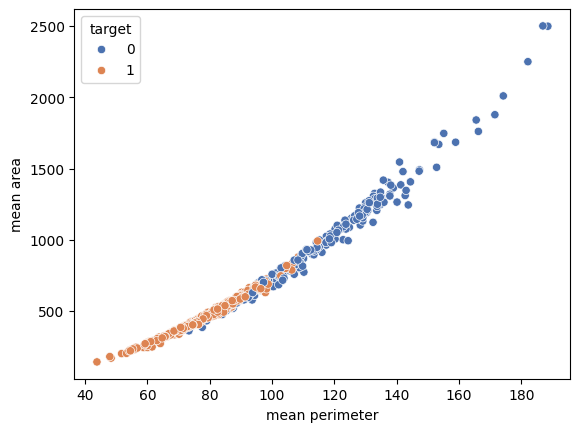

In [27]:
sns.scatterplot(data=df, x='mean perimeter', y='mean area', hue='target', palette='deep')
plt.show()

# scatter de 'mean perimeter' y 'mean area', hue es el target

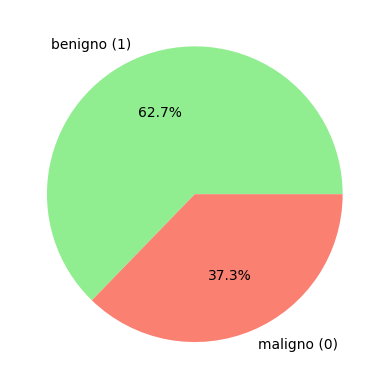

In [28]:
df['target'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['benigno (1)', 'maligno (0)'],
    colors=['lightgreen', 'salmon']
)
plt.show()
# diagrama de tarta para la distribución del target

## Modelado

In [29]:
# importa train test split
from sklearn.model_selection import train_test_split

In [30]:
# define X, y, haz train test split
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [32]:
# importa pipeline
# importa standardscaler, minmaxscaler
# importaselectkbest
# modelos Logistic regression
# modelos randomforestclassifier, gradientboostingclassifier
# knn classifier, svc
# gridsearchcv, randomizedcv
# métricas accuracy, confusion matrix, precision, recall, roc_auc

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score

In [33]:
pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest()),
    ('classifier', RandomForestClassifier())
])
pipe

# pipeline con steps standardscaler, selectkbest, y luego un randomforestclassifier

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...001F61EAB4E00>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",10
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


In [39]:
# parámetros logística selectkbest con k de 5  a 12, 3 valores
# C 0.01, 10, 1000
log_params_grid = {
    'feature_selection__k': np.linspace(5, 12, 3, dtype=int),
    'classifier': [LogisticRegression(max_iter=10000)],
    'classifier__C': [0.01, 10, 1000]
}

# randomforest con standardscaler, minmaxscaler, None
# k best de 5 a 12, 3 valores
# max_depth de 2 a 7 2 valores
rf_params_grid = {
    'scaler': [StandardScaler(), MinMaxScaler(), None],
    'feature_selection__k': np.linspace(5, 12, 3, dtype=int),
    'classifier': [RandomForestClassifier()],
    'classifier__max_depth': np.linspace(2, 7, 2, dtype=int)
}

# gradientboosting
# standardscaler, minmaxscaler, none
# k de 5 a 12, 3 valores
# max_depth de 2 a 7, 2 valores
gb_params_grid = {
    'scaler': [StandardScaler(), MinMaxScaler(), None],
    'feature_selection__k': np.linspace(5, 12, 3, dtype=int),
    'classifier': [GradientBoostingClassifier()],
    'classifier__max_depth': np.linspace(2, 7, 2, dtype=int)
}

# knn con k de 5 a 12, 3 valores
# vecinos de 5 a 15, 3 valores
knn_params_grid = {
    'feature_selection__k': np.linspace(5, 12, 3, dtype=int),
    'classifier': [KNeighborsClassifier()],
    'classifier__n_neighbors': np.linspace(5, 15, 4, dtype=int)
}

# svm con k entre 5 y 12, 3 valores
# hiperparámetro C 0.01, 10, 1000
# kernel polinómico y gaussiano
svm_params_grid = {
    'feature_selection__k': np.linspace(5, 12, 3, dtype=int),
    'classifier': [SVC()],
    'classifier__C': [0.01, 10, 1000],
    'classifier__kernel': ['poly', 'rbf']
}

search_grid = [
    log_params_grid,
    rf_params_grid,
    gb_params_grid,
    knn_params_grid,
    svm_params_grid
]


In [35]:
# posibilidades en el search
total = 0
for sub in search_grid:
    n = 1
    for v in sub.values():
        n *= len(v)
    print(sub['classifier'][0].__class__.__name__, '->', n, 'combinaciones')
    total += n
print('TOTAL:', total)

LogisticRegression -> 9 combinaciones
RandomForestClassifier -> 18 combinaciones
GradientBoostingClassifier -> 18 combinaciones
KNeighborsClassifier -> 12 combinaciones
SVC -> 18 combinaciones
TOTAL: 75


In [40]:
# gridsearchcv con 3 folds
clf_gs = GridSearchCV(
    estimator=pipe,
    param_grid=search_grid,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=2
)
clf_gs.fit(X_train, y_train)

Fitting 3 folds for each of 75 candidates, totalling 225 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier': [LogisticRegre...ax_iter=10000)], 'classifier__C': [0.01, 10, ...], 'feature_selection__k': array([ 5, 8, 12])}, {'classifier': [RandomForestClassifier()], 'classifier__max_depth': array([2, 7]), 'feature_selection__k': array([ 5, 8, 12]), 'scaler': [StandardScaler(), MinMaxScaler(), ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22

In [41]:
# best_score, best_estimator, best_params
print(clf_gs.best_score_)
print(clf_gs.best_estimator_)
print(clf_gs.best_params_)

0.9582171488323458
Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(k=np.int64(8))),
                ('classifier', LogisticRegression(C=1000, max_iter=10000))])
{'classifier': LogisticRegression(max_iter=10000), 'classifier__C': 1000, 'feature_selection__k': np.int64(8)}


In [44]:
mejor_modelo = clf_gs.best_estimator_
y_pred = mejor_modelo.predict(X_test)

print('accuracy_score', accuracy_score(y_test, y_pred))
print('precision_score', precision_score(y_test, y_pred))
print('recall_score', recall_score(y_test, y_pred))
print('roc_auc_score', roc_auc_score(y_test, y_pred))
print('confusion_matrix\n', confusion_matrix(y_test, y_pred))

accuracy_score 0.9649122807017544
precision_score 0.9722222222222222
recall_score 0.9722222222222222
roc_auc_score 0.9623015873015873
confusion_matrix
 [[40  2]
 [ 2 70]]


In [45]:
import pickle

In [48]:
pickle.dump(mejor_modelo, open('final_model.pkl', 'wb'))

In [49]:
modelo_importado = pickle.load(open("final_model.pkl", 'rb'))
modelo_importado

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...001F61EAB4E00>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",np.int64(8)
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the 

In [50]:
modelo_importado.predict(X_test)

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [51]:
modelo_importado['classifier'].coef_

array([[  4.38938234,   3.6990975 ,  -2.95879892,  -2.12208194,
          0.571888  ,  -0.79586834, -12.15093103,  -1.56983591]])

In [52]:
modelo_importado['feature_selection'].get_feature_names_out()

array(['x0', 'x2', 'x3', 'x7', 'x20', 'x22', 'x23', 'x27'], dtype=object)

In [53]:
X.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='str')

In [54]:
np.logspace(-2,4,100)

array([1.00000000e-02, 1.14975700e-02, 1.32194115e-02, 1.51991108e-02,
       1.74752840e-02, 2.00923300e-02, 2.31012970e-02, 2.65608778e-02,
       3.05385551e-02, 3.51119173e-02, 4.03701726e-02, 4.64158883e-02,
       5.33669923e-02, 6.13590727e-02, 7.05480231e-02, 8.11130831e-02,
       9.32603347e-02, 1.07226722e-01, 1.23284674e-01, 1.41747416e-01,
       1.62975083e-01, 1.87381742e-01, 2.15443469e-01, 2.47707636e-01,
       2.84803587e-01, 3.27454916e-01, 3.76493581e-01, 4.32876128e-01,
       4.97702356e-01, 5.72236766e-01, 6.57933225e-01, 7.56463328e-01,
       8.69749003e-01, 1.00000000e+00, 1.14975700e+00, 1.32194115e+00,
       1.51991108e+00, 1.74752840e+00, 2.00923300e+00, 2.31012970e+00,
       2.65608778e+00, 3.05385551e+00, 3.51119173e+00, 4.03701726e+00,
       4.64158883e+00, 5.33669923e+00, 6.13590727e+00, 7.05480231e+00,
       8.11130831e+00, 9.32603347e+00, 1.07226722e+01, 1.23284674e+01,
       1.41747416e+01, 1.62975083e+01, 1.87381742e+01, 2.15443469e+01,
      

In [55]:
log_params = {
    'feature_selection__k': np.arange(5,12),
    'classifier': [LogisticRegression()],
    'classifier__C': np.logspace(-2,4,100)
}

rf_params = {
    'scaler': [StandardScaler(), MinMaxScaler(), None],
    'feature_selection__k': np.arange(5,12),
    # 'classifier': [LogisticRegression()],
    'classifier__max_depth': np.arange(2,7),
    'classifier__min_samples_leaf': np.arange(5,20)
}

gb_params = {
    'scaler': [StandardScaler(), MinMaxScaler(), None],
    'feature_selection__k': np.arange(5,12),
    'classifier': [GradientBoostingClassifier()],
    'classifier__max_depth': np.arange(2,7),
    'classifier__learning_rate': np.logspace(-2,4,100)
}

knn_params = {
    # 'scaler': [StandardScaler(), MinMaxScaler(), None],
    'feature_selection__k': np.arange(5,12),
    'classifier': [KNeighborsClassifier()],
    'classifier__n_neighbors': np.arange(5,15)
}

svm_params = {
    # 'scaler': [StandardScaler(), MinMaxScaler(), None],
    'feature_selection__k': np.arange(5,12),
    'classifier': [SVC()],
    'classifier__C': np.logspace(-2,4,100),
    'classifier__kernel': ['poly', 'rbf']
}

search = [log_params,
         rf_params,
         gb_params,
         knn_params,
         svm_params]

In [56]:
# randomizedSearchCV
clf_rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=search,
    n_iter=100,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=2,
    random_state=42
)
clf_rs.fit(X_train, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'classifier': [LogisticRegression()], 'classifier__C': array([1.0000...00000000e+04]), 'feature_selection__k': array([ 5, 6..., 9, 10, 11])}, {'classifier__max_depth': array([2, 3, 4, 5, 6]), 'classifier__min_samples_leaf': array([ 5, 6..., 17, 18, 19]), 'feature_selection__k': array([ 5, 6..., 9, 10, 11]), 'scaler': [StandardScaler(), MinMaxScaler(), ...]}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` i

In [57]:

print(clf_rs.best_score_)
print(clf_rs.best_estimator_)
print(clf_rs.best_params_)

0.9516382014639246
Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(k=np.int64(9))),
                ('classifier', LogisticRegression(C=np.float64(100.0)))])
{'feature_selection__k': np.int64(9), 'classifier__C': np.float64(100.0), 'classifier': LogisticRegression()}


In [58]:
final_model = clf_rs.best_estimator_
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print('accuracy_score', accuracy_score(y_test, y_pred))
print('precision_score', precision_score(y_test, y_pred))
print('recall_score', recall_score(y_test, y_pred))
print('roc_auc_score', roc_auc_score(y_test, y_pred))
print('confusion_matrix\n', confusion_matrix(y_test, y_pred))

accuracy_score 0.9649122807017544
precision_score 0.9722222222222222
recall_score 0.9722222222222222
roc_auc_score 0.9623015873015873
confusion_matrix
 [[40  2]
 [ 2 70]]
